# `COMMENT TOXICITY DETECTION`

In [1]:
# Import necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import re
import string
import emoji
import contractions
import pickle
from bs4 import BeautifulSoup
from tqdm import tqdm

import pickle
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding,Bidirectional,LSTM,Dense,Dropout)
from tensorflow.keras.callbacks import (EarlyStopping,ModelCheckpoint,ReduceLROnPlateau)

# Display settings
pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\RAaM\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\RAaM\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\RAaM\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
# Load dataset
df = pd.read_csv(r"C:\Users\RAaM\OneDrive\Desktop\CommentToxicity\train.csv")

In [3]:
# Load top 5 rows 
df.head(5)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
# Print the shape and info of the dataset
print("Shape : ",df.shape)
print(df.info())

Shape :  (159571, 8)
<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             159571 non-null  str  
 1   comment_text   159571 non-null  str  
 2   toxic          159571 non-null  int64
 3   severe_toxic   159571 non-null  int64
 4   obscene        159571 non-null  int64
 5   threat         159571 non-null  int64
 6   insult         159571 non-null  int64
 7   identity_hate  159571 non-null  int64
dtypes: int64(6), str(2)
memory usage: 72.2 MB
None


In [5]:
# Checking the Statistics
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
# Checking null values
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [7]:
# Checking duplicate values
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 0


# `Binary Target Creation`

In [8]:
label_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

df["target"] = df[label_columns].max(axis=1)
df["target"].value_counts()

target
0    143346
1     16225
Name: count, dtype: int64

In [9]:
# Save Processed Data
df.to_csv(r"C:\Users\RAaM\OneDrive\Desktop\CommentToxicity\toxicity_binary.csv", index=False)
df = pd.read_csv(r"C:\Users\RAaM\OneDrive\Desktop\CommentToxicity\toxicity_binary.csv")

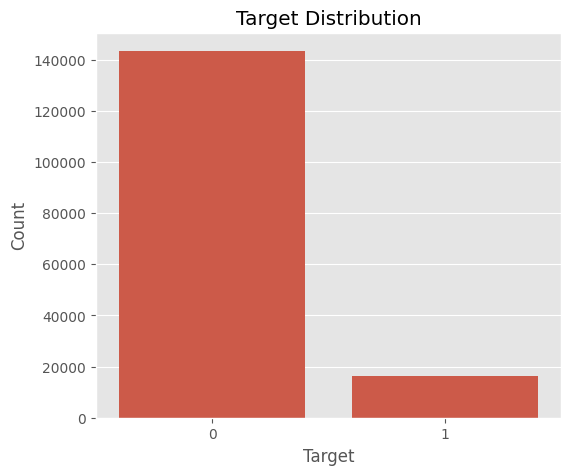

In [10]:
# Target Distribution Visualization
plt.figure(figsize=(6,5))
sns.countplot(data=df,x="target")
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()


# `EDA`

In [11]:
# Comment Length
df["comment_length"] = df["comment_text"].apply(len)
df[["comment_text","comment_length"]].head()


,comment_text,comment_length
0,Explanation\nWhy the edits made under my usern...,264
1,D'aww! He matches this background colour I'm s...,112
2,"Hey man, I'm really not trying to edit war. It...",233
3,"""\nMore\nI can't make any real suggestions on ...",622
4,"You, sir, are my hero. Any chance you remember...",67


In [12]:
# Word Count
df["word_count"] = df["comment_text"].apply(lambda x: len(str(x).split()))
df[["comment_text","word_count"]].head()

,comment_text,word_count
0,Explanation\nWhy the edits made under my usern...,43
1,D'aww! He matches this background colour I'm s...,17
2,"Hey man, I'm really not trying to edit war. It...",42
3,"""\nMore\nI can't make any real suggestions on ...",113
4,"You, sir, are my hero. Any chance you remember...",13


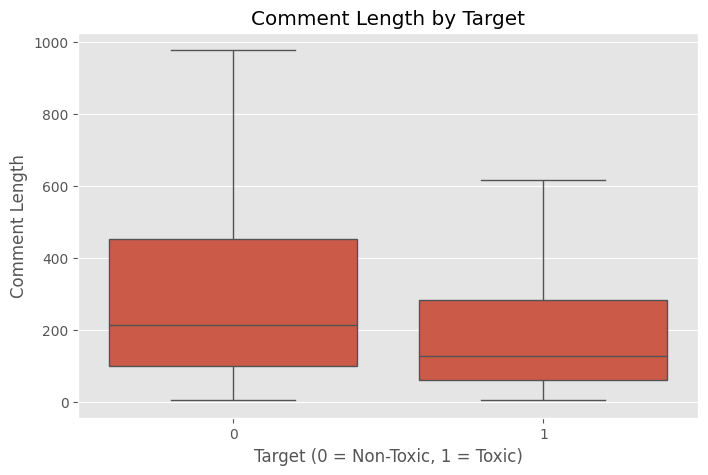

In [13]:
# Compare Toxic vs Non-Toxic Length

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="target",
    y="comment_length",
    showfliers=False
)
plt.title("Comment Length by Target")
plt.xlabel("Target (0 = Non-Toxic, 1 = Toxic)")
plt.ylabel("Comment Length")
plt.show()

# Interpretation
## 1. Toxic comments are generally concise and direct.
## 2. Non-toxic comments tend to be longer discussions.

# `WORD CLOUD(All Comments)`

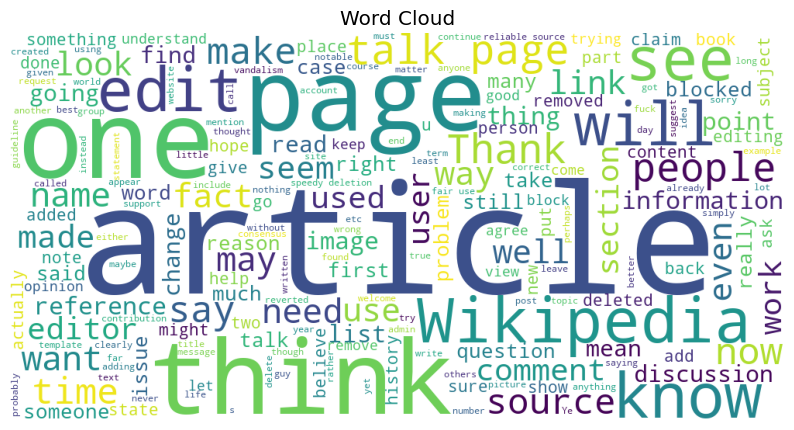

In [14]:
text = " ".join(df["comment_text"].astype(str))
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

# `WORD CLOUD(Only Toxic)`

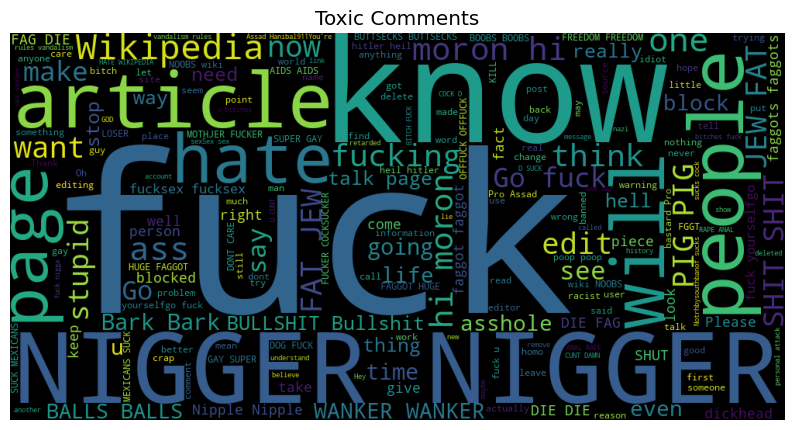

In [15]:
toxic_text = " ".join(df[df["target"]==1]["comment_text"].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="black"
).generate(toxic_text)

plt.figure(figsize=(10,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Toxic Comments")
plt.show()

# `Top 10 Most Frequent Words`

   Word   Count
0   the  445987
1    to  288817
2    of  219334
3   and  207381
4     a  201817
5     I  183930
6    is  164639
7   you  157272
8  that  140545
9    in  130262


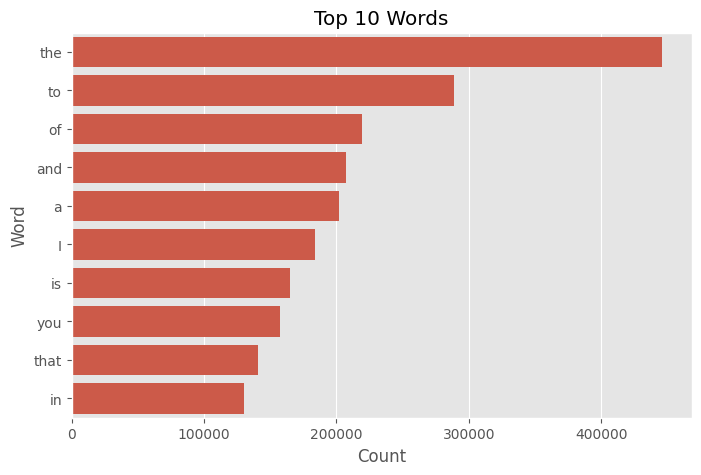

In [16]:
from collections import Counter
words = " ".join(df["comment_text"]).split()
counter = Counter(words)
top10 = counter.most_common(10)
top10_df = pd.DataFrame(top10,columns=["Word","Count"])
print(top10_df)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(
    data=top10_df,
    x="Count",
    y="Word"
)
plt.title("Top 10 Words")
plt.show()

# `TEXT PREPROCESSING`

In [17]:
# Initialize objects
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [18]:
# 1. Convert the text to Lower case
def to_lower(text):
    return text.lower()

In [19]:
# 2. Remove HTML Tags
def remove_html(text):
    return BeautifulSoup(text, "html.parser").get_text()

In [20]:
# 3. Remove URLs
def remove_urls(text):
    pattern = r"http\S+|www\S+|https\S+"
    return re.sub(pattern, "", text)

In [21]:
# 4. Expand Contractions
def expand_contractions(text):
    return contractions.fix(text)

In [22]:
# 5. Remove Emojis
def remove_emojis(text):
    return emoji.replace_emoji(text, replace="")

In [23]:
# 6. Remove Punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans("","",string.punctuation))

In [24]:
# 7. Remove Numbers
def remove_numbers(text):
    return re.sub(r"\d+", "", text)

In [25]:
# 8. Remove Extra Spaces
def remove_spaces(text):
    return re.sub(r"\s+", " ", text).strip()

In [26]:
# 9. Remove Stopwords
def remove_stopwords(text):
    words = text.split()
    words = [
        word
        for word in words
        if word not in stop_words
    ]
    return " ".join(words)

In [27]:
# 10. Lemmatization
def lemmatize(text):
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]
    return " ".join(words)

In [28]:
def preprocess_text(text):
    text = str(text)
    text = to_lower(text)
    text = remove_html(text)
    text = remove_urls(text)
    text = expand_contractions(text)
    text = remove_emojis(text)
    text = remove_punctuation(text)
    text = remove_numbers(text)
    text = remove_spaces(text)
    text = remove_stopwords(text)
    text = lemmatize(text)
    return text

tqdm.pandas()
df["clean_comment"] = df["comment_text"].progress_apply(preprocess_text)

100%|██████████| 159571/159571 [01:16<00:00, 2089.08it/s]


In [29]:
# Compare the original Comment with the cleaned Comment
pd.set_option("display.max_colwidth", None)
df[["comment_text", "clean_comment"]].head(5)

,comment_text,clean_comment
0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",explanation edits made username hardcore metallica fan reverted vandalism closure gas voted new york doll fac please remove template talk page since retired
1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",daww match background colour seemingly stuck thanks talk january utc
2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",hey man really trying edit war guy constantly removing relevant information talking edits instead talk page seems care formatting actual info
3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominations#Transport """,cannot make real suggestion improvement wondered section statistic later subsection type accident think reference may need tidying exact format ie date format etc later noone else first preference formatting style reference want please let know appears backlog article review guess may delay reviewer turn listed relevant form eg wikipediagoodarticlenominationstransport
4,"You, sir, are my hero. Any chance you remember what page that's on?",sir hero chance remember page


In [30]:
# Check for empty Comments and replace it  
empty_comments = df[df["clean_comment"].str.strip() == ""]
print("Empty Comments:", len(empty_comments))
df["clean_comment"] = df["clean_comment"].replace("", "empty")

Empty Comments: 77


In [31]:
# Save the Cleaned DataSet

df.to_csv(r"C:\Users\RAaM\OneDrive\Desktop\CommentToxicity\toxicity_clean.csv", index=False)
df = pd.read_csv(r"C:\Users\RAaM\OneDrive\Desktop\CommentToxicity\toxicity_clean.csv")

# `NLP PIPELINE`

In [32]:
# Input and Target
X = df["clean_comment"]
y = df["target"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Tokenizer
VOCAB_SIZE = 30000
tokenizer = Tokenizer(num_words=VOCAB_SIZE,oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
print("Vocabulary Size:", len(tokenizer.word_index))
print()

# Convert Text to Sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
print(X_train.iloc[0])
print(X_train_seq[0])
print()

# Inspect the distribution
lengths = [len(seq) for seq in X_train_seq]
print("Maximum Length :", max(lengths))
print("Average Length :", np.mean(lengths))
print("95th Percentile :", np.percentile(lengths, 95))

Vocabulary Size: 185370

message thanks message fun feb utc
[146, 23, 146, 895, 2052, 98]

Maximum Length : 1250
Average Length : 33.52346149025506
95th Percentile : 114.0


In [33]:
# Apply Padding

MAX_LEN = int(np.percentile(lengths, 95))
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)
print(X_train_pad.shape)
print(X_test_pad.shape)

(127656, 114)
(31915, 114)


In [34]:
# Save Tokenizer

import os
import pickle
os.makedirs("../artifacts", exist_ok=True)
with open("../artifacts/tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

In [35]:
# Save Maximum Sequence Length
config = {
    "max_len": MAX_LEN,
    "vocab_size": VOCAB_SIZE
}

with open("../artifacts/config.pkl", "wb") as file:
    pickle.dump(config, file)

In [45]:
# Hyperparameters

VOCAB_SIZE = 30000
MAX_LEN = X_train_pad.shape[1]
print(MAX_LEN)
EMBEDDING_DIM = 128

114


 # `Model Building`

In [44]:
model = Sequential([    
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),
    Bidirectional(LSTM(64,return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1,activation="sigmoid")
])


# `Model Compilation`

In [38]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# `Define Callbacks` 

In [39]:
# EarlyStopping
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# ModelCheckpoint
checkpoint = ModelCheckpoint("../artifacts/tox_model.keras", monitor="val_loss", save_best_only=True)
                             
# Reduce Learning Rate
reduce_lr = ReduceLROnPlateau(monitor="val_loss",factor=0.5, patience=2, verbose=1)                             

# `Train the Model`

In [40]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/10
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 190s 117ms/step - accuracy: 0.9518 - loss: 0.1410 - precision: 0.8442 - recall: 0.6391 - val_accuracy: 0.9590 - val_loss: 0.1108 - val_precision: 0.8239 - val_recall: 0.7788 - learning_rate: 0.0010
Epoch 2/10
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 177s 111ms/step - accuracy: 0.9701 - loss: 0.0825 - precision: 0.8839 - recall: 0.8086 - val_accuracy: 0.9598 - val_loss: 0.1152 - val_precision: 0.8610 - val_recall: 0.7396 - learning_rate: 0.0010
Epoch 3/10
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9787 - loss: 0.0567 - precision: 0.9124 - recall: 0.8717
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 192s 121ms/step - accuracy: 0.9787 - loss: 0.0567 - precision: 0.9124 - recall: 0.8717 - val_accuracy: 0.9565 - val_loss: 0.1394 - val_precision: 0.8371 - val_recall: 0.7319 - learning_rate: 0.0010
Epoch 4/10
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 184s 115ms/step - accuracy: 0.9886 - loss: 0.0

In [41]:
# Save Training History
with open("../artifacts/history.pkl", "wb") as file:
    pickle.dump(history.history, file)

In [42]:
# Save the Final Model
model.save("../artifacts/final_model.keras")